
# Random Forest — Clasificación de Gravedad en Accidentes de Tránsito

**Dataset:** Incidentes viales municipio de Envigado · 9.326 registros · 32 columnas  
**Variable respuesta:** Gravedad -> Herido (0) / Muerto (1)  
**Selección de hiperparámetros:** OOB Grid Search -> CV Grid Search → Evaluación final  
**Balanceo:** Oversampling manual con una proporción 1:5

---
Es el modelo inicial. Se plantea un Random Forest con la totalidad del dataset, para hacer un primer vistazo en el comportamiento de las diferentes variables categóricas, teniendo en cuenta las primeras observaciones sobre la variable respuesta.

## 1. Librerías y configuración

In [45]:
#-----------Tratamiento de datos----------------------------------------
import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

# Preprocesado
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterGrid
from sklearn.utils import resample

# Balanceo (alternativa — ver nota en introducción)
from imblearn.over_sampling import SMOTE

# Modelado
from sklearn.ensemble import RandomForestClassifier

# Evaluación
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
    classification_report, confusion_matrix, roc_curve, RocCurveDisplay, precision_recall_curve,
    average_precision_score
)

# Gráficos
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# OS y HTTP
# ==============================================================================
import os, sys, requests

# Rutas de salida
os.makedirs("modelos/clasificacion", exist_ok=True)
os.makedirs("modelos/scaler", exist_ok=True)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [46]:
# Parámetros globales
# ==============================================================================
GITHUB_BASE_URL           = 'https://raw.githubusercontent.com/yorbisUdeA/udea/main/'
DATASET_FILE_NAME         = 'DataSet_Accidentes.xlsx'
UTILS_FILE_NAME           = 'funciones.py'
DATASETS_PATH             = 'datasets/'
UTILS_PATH                = 'utils/'
MODELS_PATH               = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH        = os.path.join(MODELS_PATH, 'scaler')

github_dataset_url = os.path.join(GITHUB_BASE_URL, DATASETS_PATH, DATASET_FILE_NAME)
github_utils_url   = os.path.join(GITHUB_BASE_URL, UTILS_PATH, UTILS_FILE_NAME)
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path   = os.path.join(UTILS_PATH, UTILS_FILE_NAME)


In [47]:
def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.
    Args:
        url (str), path (str), description (str)
    '''
    print(f'Descargando {description} desde: {url}')
    response = requests.get(url)
    response.raise_for_status()
    with open(path, 'wb') as f:
        f.write(response.content)
    print(f'{description} descargado exitosamente a: {path}')

In [48]:
# Crear directorios y descargar archivos
# ==============================================================================
for p in [DATASETS_PATH, UTILS_PATH, MODELS_PATH, MODELS_CLASIFICACION_PATH, MODELS_SCALER_PATH]:
    os.makedirs(p, exist_ok=True)

download_file(github_dataset_url, local_dataset_path, 'dataset')
download_file(github_utils_url,   local_utils_path,   'funciones')


Descargando dataset desde: https://raw.githubusercontent.com/yorbisUdeA/udea/main/datasets/DataSet_Accidentes.xlsx
dataset descargado exitosamente a: datasets/DataSet_Accidentes.xlsx
Descargando funciones desde: https://raw.githubusercontent.com/yorbisUdeA/udea/main/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py


In [49]:
# Funciones externas del repositorio
# ==============================================================================
sys.path.append(UTILS_PATH)
from funciones import multiple_plot, plot_roc_curve

## 2. Carga del dataset

In [50]:
#-----------------------CARGAMOS EL DATASET-------------------------------

df = pd.read_excel(local_dataset_path, engine='openpyxl')
print(f"Shape: {df.shape}")
df.head(3)

Shape: (9326, 32)


,Radicado,Fecha_Accidente,Hora_Accidente,Dia_Semana,Año,Mes,Clase_Vehiculo,Tipo_Servicio,Tipo_Victima,Edad,...,Objeto_Fijo,Sector_Accidente,Condicion_Climatica,Causa_Accidente,Fecha_Accidente2,Franja_Horaria,L_Edad,T_Edad,Edad_nivel,Edad_alto
0,2173901,2018-01-02,22:50:00,Martes,2018,1,Motocicleta,Particular,Motociclista,19,...,No Reportado,Comercial,Normal,Desobedecer señales,2018-01-02,Noche,2.945312,1.303430,Joven,Adulto
1,2180000,2018-01-02,20:40:00,Martes,2018,1,Bus,Publico,Pasajero,21,...,No Reportado,Residencial,Lluvia,Desobedecer señales,2018-01-02,Noche,3.044922,1.315224,Joven,Adulto
2,2180000,2018-01-02,20:40:00,Martes,2018,1,Automovil,Particular,Conductor,31,...,No Reportado,Residencial,Lluvia,Desobedecer señales,2018-01-02,Noche,3.433594,1.362143,Adulto,Joven


In [51]:
#--------------------------Información inicial del data set--------------
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9326 entries, 0 to 9325
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Radicado              9326 non-null   int64         
 1   Fecha_Accidente       9326 non-null   datetime64[us]
 2   Hora_Accidente        9326 non-null   str           
 3   Dia_Semana            9326 non-null   str           
 4   Año                   9326 non-null   int64         
 5   Mes                   9326 non-null   int64         
 6   Clase_Vehiculo        9326 non-null   str           
 7   Tipo_Servicio         9326 non-null   str           
 8   Tipo_Victima          9326 non-null   str           
 9   Edad                  9326 non-null   int64         
 10  Genero                9326 non-null   str           
 11  Gravedad              9326 non-null   str           
 12  Estado_Embriaguez     9326 non-null   str           
 13  Consumo_Droga         9326 no

## 3. Análisis exploratorio (EDA)

In [52]:
#---------------------Distribución de la variable respuesta--------------------------------------
print("── Distribución de Gravedad ──")
print(df["Gravedad"].value_counts())
print(f"\nProporción muertos: {(df['Gravedad']=='Muertos').mean()*100:.2f}%")
print(f"Ratio desbalance : 1 muerto por cada {(df['Gravedad']=='Heridos').sum() // (df['Gravedad']=='Muertos').sum()} heridos")

── Distribución de Gravedad ──
Gravedad
Heridos    9196
Muertos     130
Name: count, dtype: int64

Proporción muertos: 1.39%
Ratio desbalance : 1 muerto por cada 70 heridos


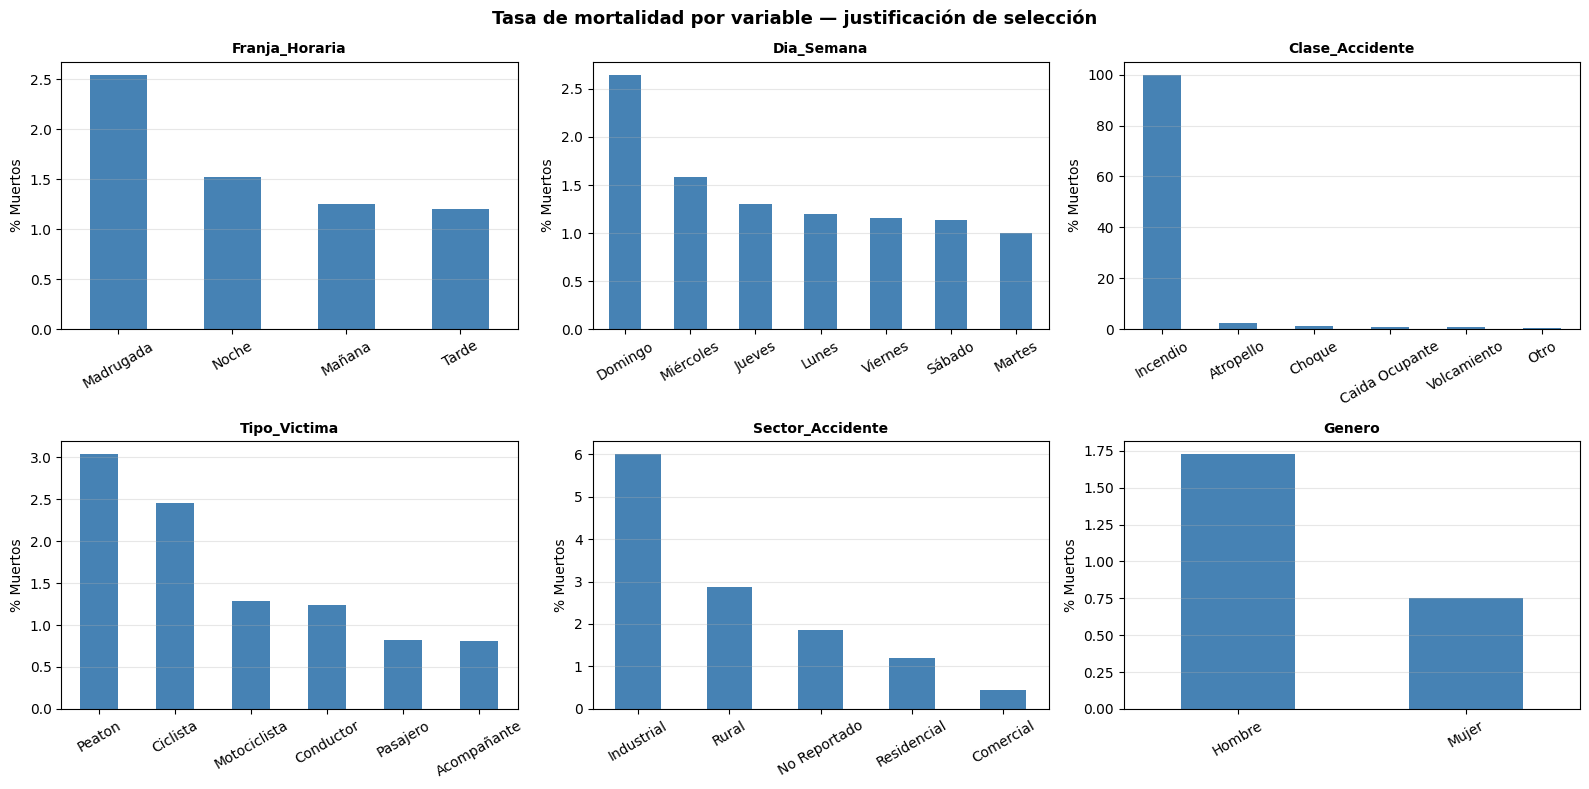

In [53]:
#------------Tasa de mortalidad por variable clave-------------------------------
df["Gravedad_bin"] = (df["Gravedad"] == "Muertos").astype(int)

vars_eda = ["Franja_Horaria","Dia_Semana","Clase_Accidente",
            "Tipo_Victima","Sector_Accidente","Genero"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Tasa de mortalidad por variable — justificación de selección",
             fontsize=13, fontweight="bold")

for ax, col in zip(axes.flatten(), vars_eda):
    g = df.groupby(col)["Gravedad_bin"].mean().sort_values(ascending=False) * 100
    g.plot(kind="bar", ax=ax, color="steelblue", edgecolor="none")
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_ylabel("% Muertos")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Preprocesamiento y selección de variables

**Por qué Label Encoding y no One-Hot Encoding:**  
Random Forest divide los datos con preguntas binarias (`variable <= umbral`)
y NO interpreta los enteros como magnitudes. Con 372 categorías en `Causa_Accidente`,
OHE generaría aprox 466 columnas adicionales innecesarias.
Label Encoding mantiene el dataset en 14 columnas — limpio y eficiente.

In [54]:
#------------Variable respuesta: Muertos=1, Heridos=0
df["Gravedad_bin"] = (df["Gravedad"] == "Muertos").astype(int)

# ----------------------Ingeniería de Hora_num: extraer hora entera de string "HH:MM:SS"
df["Hora_num"] = pd.to_numeric(
    df["Hora_Accidente"].str.split(":").str[0], errors="coerce"
).fillna(14)  # 14h = mediana

# --------------------Variables seleccionadas 
FEATURES = [
    "Franja_Horaria",     
    "Dia_Semana",        
    "Hora_num",           
    "Clase_Accidente",    
    "Clase_Vehiculo",     
    "Tipo_Victima",       
    "Sector_Accidente",   
    "Localidad_Comuna",   
    "Genero",             
    "Edad",               
    "Edad_nivel",        
    "Causa_Accidente",    
    "Condicion_Climatica",
    "Tipo_Servicio"      
]
TARGET = "Gravedad_bin"

# ------------------------------Label Encoding de variables categóricas
df_model = df[FEATURES + [TARGET]].copy()
encoders = {}
cat_cols = [c for c in FEATURES if df_model[c].dtype not in ["int64","float64"]]

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

X = df_model[FEATURES]
y = df_model[TARGET]

assert X.isnull().sum().sum() == 0, "ERROR: nulos detectados"
print(f"X shape: {X.shape} | Tasa positivos: {y.mean()*100:.2f}%")
print("✅ Preprocesamiento completo — sin nulos")

X shape: (9326, 14) | Tasa positivos: 1.39%
✅ Preprocesamiento completo — sin nulos


Al obviar el One-Hot-Encoding, también se fundamenta el hecho de no tener un patrón de agrupamiento de variables claro, ya que tenemos algunas que tienen pocas categorías dentro de su misma clasificación, y también otras (ejemplo 'Causa_Accidente') que tienen muchos datos distintivos. 

## 5. División Train / Test estratificada

`stratify=y` garantiza que ambos conjuntos mantengan la proporción 1.39% de muertos.  
**El test queda bloqueado** hasta la evaluación final (Sección 9).

In [55]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.20,    # 20% evaluación final — 26 muertos en test
    random_state=42,   # Reproducibilidad
    stratify=y         # Preservar proporción 1.39% en ambos conjuntos
)

print(f"Train: {X_tr.shape[0]} | Muertos: {y_tr.sum()} ({y_tr.mean()*100:.2f}%)")
print(f"Test : {X_te.shape[0]} | Muertos: {y_te.sum()} ({y_te.mean()*100:.2f}%)")
print("✅ Estratificación correcta — proporciones idénticas")

Train: 7460 | Muertos: 104 (1.39%)
Test : 1866 | Muertos: 26 (1.39%)
✅ Estratificación correcta — proporciones idénticas


## 6. Balanceo de clases — Oversampling 1:5

**Aplicado SOLO al train** — el test nunca se modifica.  
Con 98.6% de heridos, un modelo que prediga siempre "Herido" tendría
98.6% de accuracy sin aprender nada. El oversampling corrige esto. Se determina una razón 1:5 (20%), con respecto a los 'Heridos' para equiparar los 'Muertos'.

In [56]:
#--------- Oversampling manual con ratio 1:5 -----------------------------------
# Elegido sobre SMOTE porque con n=104 muertos en train,
# SMOTE genera muestras sintéticas poco representativas (vecinos son heridos).

tr_df   = pd.concat([X_tr, y_tr], axis=1)
mayoria = tr_df[tr_df[TARGET] == 0]   # Heridos
minoria = tr_df[tr_df[TARGET] == 1]   # Muertos

minoria_up = resample(
    minoria,
    replace=True,                      # Con reemplazo (bootstrapping)
    n_samples=len(mayoria) // 5,       # Ratio 1:5
    random_state=42
)
tr_bal = pd.concat([mayoria, minoria_up]).sample(
    frac=1, random_state=42).reset_index(drop=True)

X_tr_b = tr_bal[FEATURES]
y_tr_b = tr_bal[TARGET]

print(f"Train balanceado: {len(tr_bal)}")
print(f"Heridos: {(y_tr_b==0).sum()} | Muertos: {(y_tr_b==1).sum()} | Ratio: 1:{(y_tr_b==0).sum()//(y_tr_b==1).sum()}")

Train balanceado: 8827
Heridos: 7356 | Muertos: 1471 | Ratio: 1:5


## 7. Grid Search basado en Out-of-Bag Score

**Ventaja del OOB:** cada árbol evalúa el ~36.8% de registros que no vio
durante su entrenamiento (bootstrap). Esto da validación interna **sin costo adicional**.

**Limitación:** el OOB se calcula sobre el train balanceado (con duplicados),
lo que infla levemente las métricas. Sirve para descartar combinaciones malas
y orientar el CV Grid Search, no como estimación final.

**Métrica:** `AUC-ROC` calculado sobre `oob_decision_function_`
(más informativa que `oob_score_` / accuracy con clases desbalanceadas).

In [57]:
#------------------Grilla de hiperparámetros para búsqueda OOB-------------------------------------
param_grid_oob = ParameterGrid({
    "n_estimators"     : [200, 300],
    "max_depth"        : [8, 12],      
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf" : [3, 5, 10],
    "max_features"     : ["sqrt"],      
})

resultados_oob = []

for params in param_grid_oob:
    rf = RandomForestClassifier(
        **params,
        oob_score=True,         
        bootstrap=True,          
        class_weight="balanced", # Penalizar más errores en Muertos
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_tr_b, y_tr_b)

    # oob_decision_function_[:, 1] = P(Muerto) estimada por árboles OOB
    oob_probs = rf.oob_decision_function_[:, 1]
    mask = ~np.isnan(oob_probs)  # registros con al menos 1 árbol OOB

    oob_auc  = roc_auc_score(np.array(y_tr_b)[mask], oob_probs[mask])
    oob_aucpr = average_precision_score(np.array(y_tr_b)[mask], oob_probs[mask])

    resultados_oob.append({
        **params,
        "oob_auc"  : oob_auc,
        "oob_aucpr": oob_aucpr,
        "oob_acc"  : rf.oob_score_,  # accuracy OOB (referencia)
    })

oob_df = pd.DataFrame(resultados_oob).sort_values("oob_auc", ascending=False)
print(f"Combinaciones evaluadas: {len(oob_df)}")
oob_df.head(10)

Combinaciones evaluadas: 36


,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,oob_auc,oob_aucpr,oob_acc
19,12,sqrt,3,5,300,0.999498,0.997324,0.986859
18,12,sqrt,3,5,200,0.999477,0.997194,0.986972
21,12,sqrt,3,10,300,0.999358,0.996624,0.985839
25,12,sqrt,5,5,300,0.999283,0.996203,0.984140
27,12,sqrt,5,10,300,0.999283,0.996203,0.984140
20,12,sqrt,3,10,200,0.999280,0.996170,0.984593
26,12,sqrt,5,10,200,0.999214,0.995831,0.984140
24,12,sqrt,5,5,200,0.999214,0.995831,0.984140
23,12,sqrt,3,20,300,0.999165,0.995459,0.984479
22,12,sqrt,3,20,200,0.999151,0.995449,0.984366


In [58]:
# -------------------------Efecto de max_depth — el hiperparámetro más determinante en OOB GS
print("Efecto de max_depth en OOB AUC")
print(oob_df.groupby("max_depth")["oob_auc"].agg(["mean","max","min"]).round(4))

# Columnas de hiperparámetros (definidas explícitamente — ParameterGrid.param_grid es lista)
param_cols_oob = ["n_estimators", "max_depth", "min_samples_split",
                  "min_samples_leaf", "max_features"]

#------------------------ Mejor combinación OOB
best_oob = oob_df.iloc[0]
print(f"\nMejor OOB: {best_oob[param_cols_oob].to_dict()}")
print(f"OOB AUC-ROC : {best_oob['oob_auc']:.4f}")
print(f"OOB AUC-PR  : {best_oob['oob_aucpr']:.4f}")
print(f"OOB Accuracy: {best_oob['oob_acc']:.4f}  (inflado por oversampling)")

# max_depth óptimo identificado → fijarlo para CV Grid Search
BEST_DEPTH_OOB = int(best_oob["max_depth"])
print(f"\nmax_depth={BEST_DEPTH_OOB} se fija para el CV Grid Search")

Efecto de max_depth en OOB AUC
             mean     max     min
max_depth                        
8          0.9845  0.9861  0.9828
12         0.9990  0.9995  0.9985

Mejor OOB: {'n_estimators': 300, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
OOB AUC-ROC : 0.9995
OOB AUC-PR  : 0.9973
OOB Accuracy: 0.9869  (inflado por oversampling)

max_depth=12 se fija para el CV Grid Search


## 8. Grid Search con Cross-Validation

**Ventaja del CV:** evalúa cada combinación sobre K particiones rotativas
del train original (sin oversampling). El oversampling se aplica
**dentro de cada fold** para evitar data leakage.

**Regla crítica:** si se aplica oversampling ANTES de crear los folds,
los duplicados sintéticos aparecen tanto en train como en validación
→ métricas artificialmente infladas.

In [59]:
#--------------------------------Grilla CV — max_depth fijado por hallazgo OOB
from itertools import product as iterproduct

param_grid_cv = {
    "n_estimators"     : [200, 300],
    "max_depth"        : [BEST_DEPTH_OOB],  # fijado por OOB GS
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf" : [3, 5, 10],
    "max_features"     : ["sqrt"],
}
combos_cv = [dict(zip(param_grid_cv, v))
             for v in iterproduct(*param_grid_cv.values())]
K = 5    #-------Número de folders----------------------------------
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

print(f"Combinaciones: {len(combos_cv)} | Folds: {K} | Entrenamientos: {len(combos_cv)*K}")
print("Métrica: AUC-ROC media sobre K folds\n")

resultados_cv = []

for params in combos_cv:
    fold_aucs, fold_prs = [], []

    for tr_idx, val_idx in skf.split(X_tr, y_tr):
        Xf_tr  = X_tr.iloc[tr_idx];  Xf_val = X_tr.iloc[val_idx]
        yf_tr  = y_tr.iloc[tr_idx];  yf_val = y_tr.iloc[val_idx]

        # Oversampling 1:5 SOLO sobre el train interno del fold
        fold_df  = pd.concat([Xf_tr, yf_tr], axis=1)
        may_f    = fold_df[fold_df[TARGET] == 0]
        mino_f   = fold_df[fold_df[TARGET] == 1]
        mino_up  = resample(mino_f, replace=True,
                            n_samples=len(may_f)//5, random_state=42)
        fold_bal = pd.concat([may_f, mino_up]).sample(
                       frac=1, random_state=42).reset_index(drop=True)

        rf = RandomForestClassifier(
            **params, class_weight="balanced",
            random_state=42, n_jobs=-1
        )
        rf.fit(fold_bal[FEATURES], fold_bal[TARGET])
        yp = rf.predict_proba(Xf_val)[:, 1]

        fold_aucs.append(roc_auc_score(yf_val, yp))
        fold_prs.append(average_precision_score(yf_val, yp))

    resultados_cv.append({
        **params,
        "cv_auc_mean": np.mean(fold_aucs),
        "cv_auc_std" : np.std(fold_aucs),
        "cv_pr_mean" : np.mean(fold_prs),
        "fold_aucs"  : fold_aucs,
    })

cv_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "fold_aucs"}
    for r in resultados_cv
]).sort_values("cv_auc_mean", ascending=False)

print("\n── Ranking CV Grid Search ──")
print(cv_df[["n_estimators","max_depth","min_samples_split",
             "min_samples_leaf","cv_auc_mean","cv_auc_std","cv_pr_mean"]].to_string(index=False))

Combinaciones: 18 | Folds: 5 | Entrenamientos: 90
Métrica: AUC-ROC media sobre K folds


── Ranking CV Grid Search ──
 n_estimators  max_depth  min_samples_split  min_samples_leaf  cv_auc_mean  cv_auc_std  cv_pr_mean
          300         12                 20                10     0.645078    0.021655    0.086828
          300         12                 10                10     0.645078    0.021655    0.086828
          300         12                  5                10     0.645078    0.021655    0.086828
          200         12                 10                10     0.644606    0.018915    0.084548
          200         12                 20                10     0.644606    0.018915    0.084548
          200         12                  5                10     0.644606    0.018915    0.084548
          200         12                 20                 3     0.634542    0.028398    0.090174
          300         12                 20                 3     0.634511    0.023946    

In [60]:
# -----------------Análisis del hiperparámetro más determinante
print("Efecto de min_samples_leaf en CV AUC-ROC")
print(cv_df.groupby("min_samples_leaf")["cv_auc_mean"].agg(["mean","max"]).round(4))

# ---------------Mejor combinación CV
best_cv_row = cv_df.iloc[0]
BEST_PARAMS = {
    "n_estimators"     : int(best_cv_row["n_estimators"]),
    "max_depth"        : int(best_cv_row["max_depth"]),
    "min_samples_split": int(best_cv_row["min_samples_split"]),
    "min_samples_leaf" : int(best_cv_row["min_samples_leaf"]),
    "max_features"     : best_cv_row["max_features"],
}
print(f"\nMejores parámetros CV: {BEST_PARAMS}")
print(f"  CV AUC-ROC: {best_cv_row['cv_auc_mean']:.4f} ± {best_cv_row['cv_auc_std']:.4f}")
print(f"  CV AUC-PR : {best_cv_row['cv_pr_mean']:.4f}")

Efecto de min_samples_leaf en CV AUC-ROC
                    mean     max
min_samples_leaf                
3                 0.6265  0.6345
5                 0.6311  0.6344
10                0.6448  0.6451

Mejores parámetros CV: {'n_estimators': 300, 'max_depth': 12, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
  CV AUC-ROC: 0.6451 ± 0.0217
  CV AUC-PR : 0.0868


## 9. Modelo final y evaluación en Test

Se reentrena con **todo el train** usando los mejores parámetros del CV GS.
El test se usa por **primera y única vez** aquí.

In [61]:
# ------------------Entrenamiento final con todos los datos de train
modelo_final = RandomForestClassifier(
    **BEST_PARAMS,
    class_weight="balanced",   #------------Balanceo de clase en modelo (penaliza)
    random_state=42,
    n_jobs=-1
)
modelo_final.fit(X_tr_b, y_tr_b)

# --------------------Umbral óptimo: maximiza F1 de la clase Muertos sobre el train
y_prob_tr = modelo_final.predict_proba(X_tr_b)[:, 1]
best_f1, UMBRAL = 0, 0.50
for t in np.arange(0.05, 0.70, 0.01):
    f1 = f1_score(y_tr_b, (y_prob_tr>=t).astype(int),
                  pos_label=1, zero_division=0)
    if f1 > best_f1: best_f1, UMBRAL = f1, t

print(f"Umbral óptimo: {UMBRAL:.2f}  (F1 train={best_f1:.4f})")

# ------------ EVALUACIÓN FINAL EN TEST--------------------------
y_prob_te = modelo_final.predict_proba(X_te)[:, 1]
y_pred_te = (y_prob_te >= UMBRAL).astype(int)
cm = confusion_matrix(y_te, y_pred_te)

print(f"\nMétricas Test")
print(f"AUC-ROC  : {roc_auc_score(y_te, y_prob_te):.4f}")
print(f"AUC-PR   : {average_precision_score(y_te, y_prob_te):.4f}  (baseline={y_te.mean():.4f})")
print(f"F1-Muerto: {f1_score(y_te, y_pred_te, pos_label=1, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_te, y_pred_te, pos_label=1, zero_division=0):.4f}")
print(f"Precision: {precision_score(y_te, y_pred_te, pos_label=1, zero_division=0):.4f}")
print(f"\n{classification_report(y_te, y_pred_te, target_names=['Herido','Muerto'])}")

Umbral óptimo: 0.60  (F1 train=0.9771)

Métricas Test
AUC-ROC  : 0.6626
AUC-PR   : 0.0267  (baseline=0.0139)
F1-Muerto: 0.0476
Recall   : 0.0385
Precision: 0.0625

              precision    recall  f1-score   support

      Herido       0.99      0.99      0.99      1840
      Muerto       0.06      0.04      0.05        26

    accuracy                           0.98      1866
   macro avg       0.52      0.52      0.52      1866
weighted avg       0.97      0.98      0.98      1866



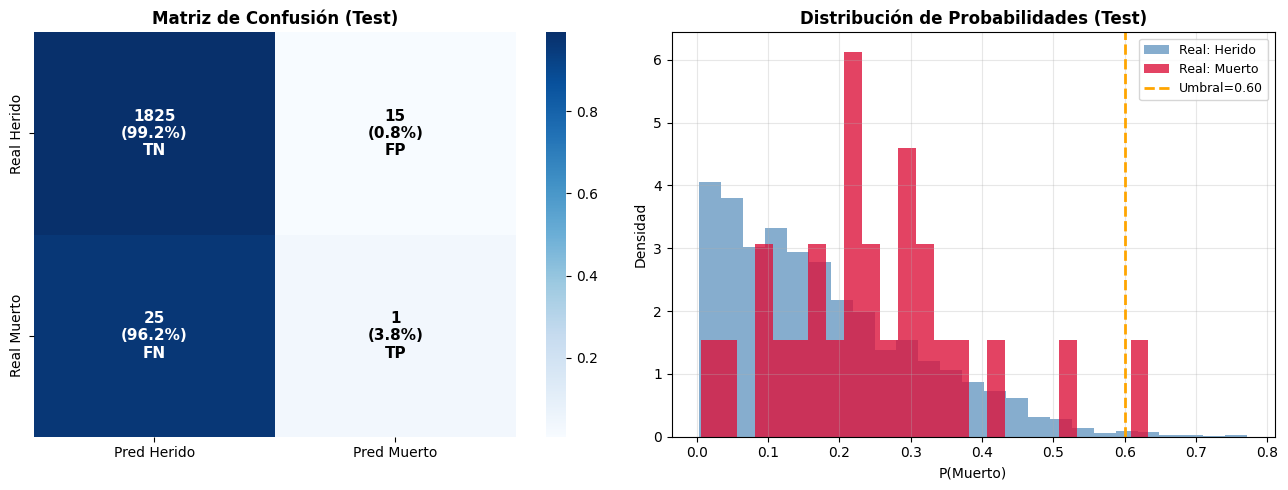

In [62]:
#------------------------Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ----------------------Heatmap----------------------
norm_cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(norm_cm, annot=False, cmap="Blues", ax=axes[0])
for i in range(2):
    for j in range(2):
        etiq = ["TN","FP","FN","TP"][i*2+j]
        axes[0].text(j+0.5, i+0.5,
            f"{cm[i,j]}\n({norm_cm[i,j]:.1%})\n{etiq}",
            ha="center", va="center", fontsize=11, fontweight="bold",
            color="white" if norm_cm[i,j]>0.5 else "black")
axes[0].set_xticklabels(["Pred Herido","Pred Muerto"])
axes[0].set_yticklabels(["Real Herido","Real Muerto"])
axes[0].set_title("Matriz de Confusión (Test)", fontweight="bold")

# -------------------Se evidencian probabilidades y su distribución---------------------
y_te_arr = np.array(y_te)
axes[1].hist(y_prob_te[y_te_arr==0], bins=25, alpha=0.65,
             color="steelblue", label="Real: Herido", density=True)
axes[1].hist(y_prob_te[y_te_arr==1], bins=25, alpha=0.80,
             color="crimson", label="Real: Muerto", density=True)
axes[1].axvline(x=UMBRAL, color="orange", lw=2, linestyle="--",
                label=f"Umbral={UMBRAL:.2f}")
axes[1].set_xlabel("P(Muerto)")
axes[1].set_ylabel("Densidad")
axes[1].set_title("Distribución de Probabilidades (Test)", fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Importancia de variables

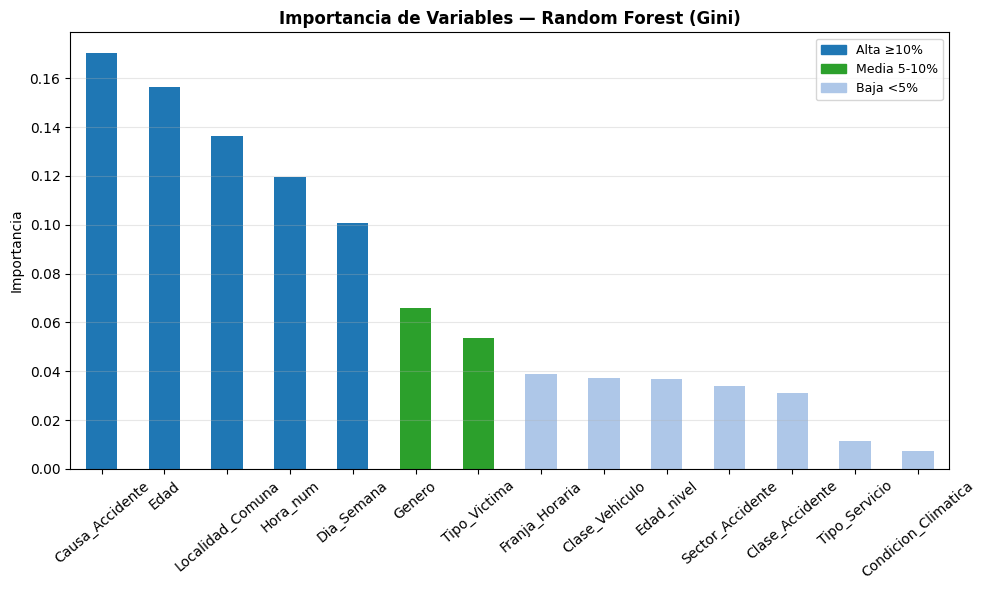


Top 5 variables:
  Causa_Accidente           0.1703  ███████████████████████████████████████████████████
  Edad                      0.1565  ██████████████████████████████████████████████
  Localidad_Comuna          0.1362  ████████████████████████████████████████
  Hora_num                  0.1197  ███████████████████████████████████
  Dia_Semana                0.1008  ██████████████████████████████


In [63]:
importancia = pd.Series(
    modelo_final.feature_importances_, index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#1f77b4" if v>=0.10 else "#2ca02c" if v>=0.05
          else "#aec7e8" for v in importancia.values]
importancia.plot(kind="bar", ax=ax, color=colors, edgecolor="none")
ax.set_title("Importancia de Variables — Random Forest (Gini)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Importancia")
ax.tick_params(axis="x", rotation=40)
ax.grid(axis="y", alpha=0.3)

p1 = mpatches.Patch(color="#1f77b4", label="Alta ≥10%")
p2 = mpatches.Patch(color="#2ca02c", label="Media 5-10%")
p3 = mpatches.Patch(color="#aec7e8", label="Baja <5%")
ax.legend(handles=[p1,p2,p3], fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 5 variables:")
for feat, val in importancia.head(5).items():
    print(f"  {feat:<25} {val:.4f}  {'█'*int(val*300)}")

## 11. Guardar modelo y función de predicción

In [64]:
# ------------------Guardar modelos-----------------------------------------
artifacts = {
    "modelo"      : modelo_final,
    "encoders"    : encoders,
    "features"    : FEATURES,
    "target"      : TARGET,
    "umbral"      : UMBRAL,
    "best_params" : BEST_PARAMS,
    "importancia" : importancia,
}

joblib.dump(artifacts, os.path.join(MODELS_CLASIFICACION_PATH, 'RandomForest_Accidentes.pkl'))
print('Modelo entrenado y guardado.')

Modelo entrenado y guardado.


Se prueba el modelo a través de datos estipulados, con un clara clasificación, pues los parámetros representan un "rótulo" de riesgo 'Alto_Riesgo' y 'Bajo_Riesgo', pudiendo observar así el márgen de probabilidades.

In [65]:
def predecir_gravedad(nuevo_accidente: dict,
                      path: str = "C:\\Users\\Santiago\\Desktop\\Esp\\venv\\RF3_Gravedad_Accidente.pkl") -> dict:
    """
    Predice la probabilidad de mortalidad para un nuevo accidente.

    Parámetros
    ----------
    nuevo_accidente : dict con las 14 variables del modelo
        Ejemplo:
        {
            "Franja_Horaria"     : "Madrugada",
            "Dia_Semana"         : "Domingo",
            "Hora_num"           : 2,
            "Clase_Accidente"    : "Atropello",
            "Clase_Vehiculo"     : "Motocicleta",
            "Tipo_Victima"       : "Peaton",
            "Sector_Accidente"   : "Rural",
            "Localidad_Comuna"   : "El Escobero",
            "Genero"             : "Hombre",
            "Edad"               : 55,
            "Edad_nivel"         : "Viejo",
            "Causa_Accidente"    : "Impericia en el manejo",
            "Condicion_Climatica": "Normal",
            "Tipo_Servicio"      : "Particular",
        }
    """
    import joblib, pandas as pd
    art = joblib.load(path)
    row = {}
    for feat in art["features"]:
        val = nuevo_accidente.get(feat)
        if feat in art["encoders"]:
            enc = art["encoders"][feat]
            vs  = str(val)
            row[feat] = enc.transform([vs])[0] if vs in enc.classes_ else -1
        else:
            row[feat] = float(val)
    X_new = pd.DataFrame([row])[art["features"]]
    prob  = art["modelo"].predict_proba(X_new)[0, 1]
    pred  = int(prob >= art["umbral"])
    nivel = "ALTO" if prob >= 0.70 else "MEDIO" if prob >= 0.40 else "BAJO"
    return {
        "probabilidad_muerte": round(float(prob), 4),
        "prediccion"         : "Muerto" if pred else "Herido",
        "nivel_riesgo"       : nivel,
        "umbral_usado"       : round(art["umbral"], 2),
    }


# -----------------------Ejemplos de predicción -------------------------------
casos = {
    "Alto riesgo": {
        "Franja_Horaria":"Madrugada","Dia_Semana":"Domingo","Hora_num":2,
        "Clase_Accidente":"Atropello","Clase_Vehiculo":"Motocicleta",
        "Tipo_Victima":"Peaton","Sector_Accidente":"Rural",
        "Localidad_Comuna":"El Escobero","Genero":"Hombre","Edad":55,
        "Edad_nivel":"Viejo","Causa_Accidente":"Impericia en el manejo",
        "Condicion_Climatica":"Normal","Tipo_Servicio":"Particular",
    },
    "Bajo riesgo": {
        "Franja_Horaria":"Tarde","Dia_Semana":"Martes","Hora_num":14,
        "Clase_Accidente":"Caida Ocupante","Clase_Vehiculo":"Motocicleta",
        "Tipo_Victima":"Acompañante","Sector_Accidente":"Comercial",
        "Localidad_Comuna":"El Centro","Genero":"Mujer","Edad":25,
        "Edad_nivel":"Joven","Causa_Accidente":"Desobedecer señales",
        "Condicion_Climatica":"Normal","Tipo_Servicio":"Particular",
    },
}
for nombre, caso in casos.items():
    r = predecir_gravedad(caso)
    print(f"\n{nombre}:")
    print(f"  P(Muerto)    : {r['probabilidad_muerte']:.4f} ({r['probabilidad_muerte']*100:.2f}%)")
    print(f"  Predicción   : {r['prediccion']}")
    print(f"  Nivel riesgo : {r['nivel_riesgo']}")


Alto riesgo:
  P(Muerto)    : 0.5000 (50.00%)
  Predicción   : Herido
  Nivel riesgo : MEDIO

Bajo riesgo:
  P(Muerto)    : 0.0257 (2.57%)
  Predicción   : Herido
  Nivel riesgo : BAJO
